2.1 Load data

In [ ]:
import pandas as pd

df = pd.read_csv("data/claims_synth.csv")
df.shape, df.head(3)

2.2 Basic schema + missingness

2.2 Basic schema + missingness

In [ ]:
df.info()

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

2.3 Label distribution (imbalance check)

In [4]:
df["fraud_label"].value_counts(normalize=True)

fraud_label
0    0.973333
1    0.026667
Name: proportion, dtype: float64

In [20]:
df["fraud_label"].mean()

np.float64(0.02666666666666667)

In [5]:
df["auto_approve_label"].value_counts(normalize=True)

auto_approve_label
0    0.612667
1    0.387333
Name: proportion, dtype: float64

2.4 Quick data quality checks

In [ ]:
df.describe(include="all").T.head(25)

In [7]:
# duplicate claim_id check
df["claim_id"].duplicated().sum()

np.int64(0)

2.5 Simple plots (EDA)

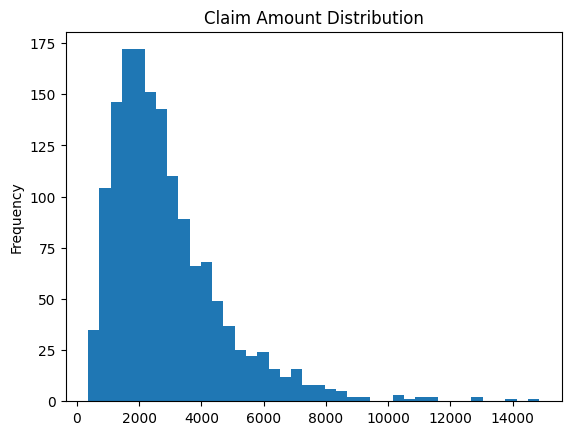

In [8]:
import matplotlib.pyplot as plt

df["claim_amount"].plot(kind="hist", bins=40)
plt.title("Claim Amount Distribution")
plt.show()

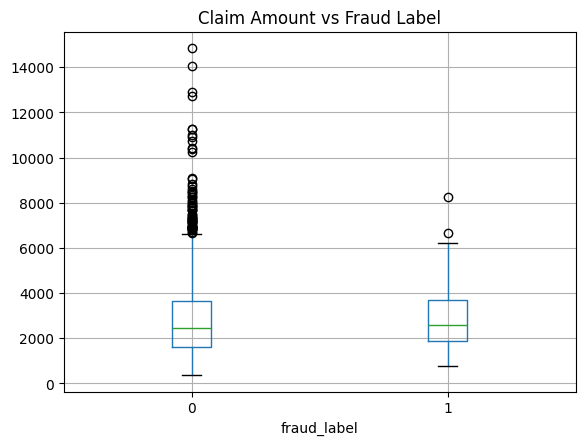

In [9]:
df.boxplot(column="claim_amount", by="fraud_label")
plt.title("Claim Amount vs Fraud Label")
plt.suptitle("")
plt.show()

Step 3: Proper split (avoid leakage) by time

In [15]:
df["service_date"] = pd.to_datetime(df["service_date"])
df = df.sort_values("service_date")

n = len(df)
train = df.iloc[: int(0.7*n)]
val   = df.iloc[int(0.7*n): int(0.85*n)]
test  = df.iloc[int(0.85*n):]

train.shape, val.shape, test.shape

((1050, 26), (225, 26), (225, 26))

Step 4: Feature set (first pass)

In [16]:
num_cols = [
    "member_age","prior_claims_90d","ed_visits_180d","chronic_index","member_tenure_months",
    "claim_amount","fraud_signal_score","review_risk_score"
]
cat_cols = [
    "member_gender","state","plan_type","provider_specialty","place_of_service",
    "inpatient_flag","out_of_network","prior_auth_required"
]
text_cols = ["clinical_notes","call_center_notes"]  # we’ll use later

Step 5: Baseline model (Fraud) — fast + interview-friendly

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

X_train = train[num_cols + cat_cols]
y_train = train["fraud_label"]
X_val   = val[num_cols + cat_cols]
y_val   = val["fraud_label"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
    ]
)

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf.fit(X_train, y_train)
pred_proba = clf.predict_proba(X_val)[:,1]
print("PR-AUC:", average_precision_score(y_val, pred_proba))

PR-AUC: 0.06314219114219115


/Users/karthik/AI_ML_Workspace/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
import numpy as np

k = int(0.05 * len(y_val))  # top 5%
top_idx = np.argsort(-pred_proba)[:k]

recall_at_k = y_val.iloc[top_idx].sum() / y_val.sum() if y_val.sum() > 0 else 0
precision_at_k = y_val.iloc[top_idx].mean()

print("Top 5% Precision:", precision_at_k)
print("Top 5% Recall:", recall_at_k)
print("Positives in val:", int(y_val.sum()), "out of", len(y_val))

Top 5% Precision: 0.0
Top 5% Recall: 0.0
Positives in val: 5 out of 225


In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
import numpy as np

hgb = Pipeline([
    ("prep", preprocess),
    ("model", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300
    ))
])

hgb.fit(X_train, y_train)
pred_proba_hgb = hgb.predict_proba(X_val)[:, 1]

print("HGB PR-AUC:", average_precision_score(y_val, pred_proba_hgb))

for pct in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(pct * len(y_val)))
    top_idx = np.argsort(-pred_proba_hgb)[:k]
    recall_k = y_val.iloc[top_idx].sum() / y_val.sum() if y_val.sum() > 0 else 0
    precision_k = y_val.iloc[top_idx].mean()
    print(f"HGB Top {int(pct*100)}% k={k:3d} | Precision={precision_k:.3f} | Recall={recall_k:.3f}")

HGB PR-AUC: 0.08386926276441267
HGB Top 1% k=  2 | Precision=0.000 | Recall=0.000
HGB Top 5% k= 11 | Precision=0.091 | Recall=0.200
HGB Top 10% k= 22 | Precision=0.091 | Recall=0.400
HGB Top 20% k= 45 | Precision=0.044 | Recall=0.400


In [24]:
import numpy as np
from sklearn.metrics import average_precision_score

print("PR-AUC:", average_precision_score(y_val, pred_proba))
print("Val positives:", int(y_val.sum()), "out of", len(y_val))

for pct in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(pct * len(y_val)))
    top_idx = np.argsort(-pred_proba)[:k]
    recall_k = y_val.iloc[top_idx].sum() / y_val.sum() if y_val.sum() > 0 else 0
    precision_k = y_val.iloc[top_idx].mean()
    print(f"Top {int(pct*100)}%  k={k:3d} | Precision={precision_k:.3f} | Recall={recall_k:.3f}")

PR-AUC: 0.06314219114219115
Val positives: 5 out of 225
Top 1%  k=  2 | Precision=0.000 | Recall=0.000
Top 5%  k= 11 | Precision=0.000 | Recall=0.000
Top 10%  k= 22 | Precision=0.045 | Recall=0.200
Top 20%  k= 45 | Precision=0.044 | Recall=0.400


Step 6: Threshold tuning (cost-aware)

6.1 Build a confusion matrix at different thresholds

Use the HGB probabilities (pred_proba_hgb) on validation.

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def eval_at_threshold(y_true, proba, thr):
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return {"thr": thr, "tp": tp, "fp": fp, "fn": fn, "tn": tn, "precision": prec, "recall": rec, "f1": f1}

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rows = [eval_at_threshold(y_val.values, pred_proba_hgb, t) for t in thresholds]
rows

[{'thr': 0.05,
  'tp': np.int64(0),
  'fp': np.int64(3),
  'fn': np.int64(5),
  'tn': np.int64(217),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'thr': 0.1,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'thr': 0.15,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'thr': 0.2,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'thr': 0.25,
  'tp': np.int64(0),
  'fp': np.int64(1),
  'fn': np.int64(5),
  'tn': np.int64(219),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'thr': 0.3,
  'tp': np.int64(0),
  'fp': np.int64(1),
  'fn': np.int64(5),
  'tn': np.int64(219),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0}]

6.2 Pick a threshold based on business cost (fraud)

In fraud:
	•	False Negative (FN) = missed fraud = very costly
	•	False Positive (FP) = investigating good claim = moderate cost

Example cost assumption (you can tweak):
	•	FN cost = 10
	•	FP cost = 1


In [26]:
FN_COST = 10
FP_COST = 1

for r in rows:
    cost = FN_COST*r["fn"] + FP_COST*r["fp"]
    r["cost"] = cost

sorted(rows, key=lambda x: x["cost"])

[{'thr': 0.25,
  'tp': np.int64(0),
  'fp': np.int64(1),
  'fn': np.int64(5),
  'tn': np.int64(219),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'cost': np.int64(51)},
 {'thr': 0.3,
  'tp': np.int64(0),
  'fp': np.int64(1),
  'fn': np.int64(5),
  'tn': np.int64(219),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'cost': np.int64(51)},
 {'thr': 0.1,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'cost': np.int64(52)},
 {'thr': 0.15,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'cost': np.int64(52)},
 {'thr': 0.2,
  'tp': np.int64(0),
  'fp': np.int64(2),
  'fn': np.int64(5),
  'tn': np.int64(218),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'cost': np.int64(52)},
 {'thr': 0.05,
  'tp': np.int64(0),
  'fp': np.int64(3),
  'fn': np.int64(5),
  'tn': np.int64(217),
  'precision': 0.0,
  

Step 7: Probability calibration (healthcare-grade)

HGB gives decent ranking, but the probabilities may not be well-calibrated. Calibration is a huge plus in interviews.

7.1 Calibrate using isotonic or sigmoid

We’ll calibrate on validation-like data, so we do it properly using train+val split.

For now (simple), calibrate using sigmoid:

In [27]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, average_precision_score

# fit a calibrated version of HGB using train set, calibrate via internal CV
hgb_base = Pipeline([
    ("prep", preprocess),
    ("model", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300
    ))
])

cal = CalibratedClassifierCV(hgb_base, method="sigmoid", cv=3)
cal.fit(X_train, y_train)

proba_cal = cal.predict_proba(X_val)[:,1]

print("Calibrated PR-AUC:", average_precision_score(y_val, proba_cal))
print("Brier score (lower better):", brier_score_loss(y_val, proba_cal))

Calibrated PR-AUC: 0.03142695287870534
Brier score (lower better): 0.021789271886950005


Step 8: TF-IDF + model (Notebook 04_feature_engineering.ipynb) error below cell 

In [36]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import average_precision_score

# Prepare text
train_text = train.copy()
val_text = val.copy()
for c in ["clinical_notes", "call_center_notes"]:
    train_text[c] = train_text[c].fillna("")
    val_text[c] = val_text[c].fillna("")
train_text["combined_notes"] = train_text["clinical_notes"] + " " + train_text["call_center_notes"]
val_text["combined_notes"] = val_text["clinical_notes"] + " " + val_text["call_center_notes"]

X_train2 = train_text[num_cols + cat_cols + ["combined_notes"]]
y_train2 = train_text["fraud_label"]
X_val2   = val_text[num_cols + cat_cols + ["combined_notes"]]
y_val2   = val_text["fraud_label"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", MaxAbsScaler())   # sparse-friendly scaling
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),

        ("txt", TfidfVectorizer(
            max_features=8000,
            ngram_range=(1,2),
            min_df=2
        ), "combined_notes"),
    ]
)

svm = Pipeline([
    ("prep", preprocess),
    ("model", LinearSVC(class_weight="balanced", random_state=42))
])

svm.fit(X_train2, y_train2)

# decision_function gives a ranking score (higher = more fraud-like)
scores = svm.decision_function(X_val2)

print("TFIDF+LinearSVC PR-AUC (using scores):", average_precision_score(y_val2, scores))

for pct in [0.05, 0.10, 0.20]:
    k = max(1, int(pct * len(y_val2)))
    top_idx = np.argsort(-scores)[:k]
    recall_k = y_val2.iloc[top_idx].sum() / y_val2.sum()
    precision_k = y_val2.iloc[top_idx].mean()
    print(f"Top {int(pct*100)}% k={k} | Precision={precision_k:.3f} | Recall={recall_k:.3f}")

print("score min/max:", float(np.min(scores)), float(np.max(scores)))

TFIDF+LinearSVC PR-AUC (using scores): 0.0883684048142136
Top 5% k=11 | Precision=0.091 | Recall=0.200
Top 10% k=22 | Precision=0.045 | Recall=0.200
Top 20% k=45 | Precision=0.044 | Recall=0.400
score min/max: -4.725780242233429 2.424673211157346


10.1 Build routes on validation using your SVC scores


In [37]:
import numpy as np

val_out = val_text.copy().reset_index(drop=True)
val_out["fraud_score"] = scores

SIU_PCT = 0.10     # top 10%
CLIN_PCT = 0.30    # next 30%

n = len(val_out)
k_siu = max(1, int(SIU_PCT * n))
k_clin = max(1, int(CLIN_PCT * n))

idx_sorted = np.argsort(-val_out["fraud_score"].values)

val_out["route"] = "AUTO_LANE"
val_out.loc[idx_sorted[:k_siu], "route"] = "SIU_REVIEW"
val_out.loc[idx_sorted[k_siu:k_siu+k_clin], "route"] = "CLINICIAN_REVIEW"

val_out["route"].value_counts()

route
AUTO_LANE           136
CLINICIAN_REVIEW     67
SIU_REVIEW           22
Name: count, dtype: int64

10.2 Measure fraud capture + leakage (most important metric)

In [38]:
def lane_stats(df, lane):
    sub = df[df["route"] == lane]
    return {
        "lane": lane,
        "count": len(sub),
        "frauds": int(sub["fraud_label"].sum()),
        "fraud_rate": float(sub["fraud_label"].mean()) if len(sub) else 0.0
    }

stats = [lane_stats(val_out, l) for l in ["SIU_REVIEW","CLINICIAN_REVIEW","AUTO_LANE"]]
stats

[{'lane': 'SIU_REVIEW',
  'count': 22,
  'frauds': 1,
  'fraud_rate': 0.045454545454545456},
 {'lane': 'CLINICIAN_REVIEW',
  'count': 67,
  'frauds': 4,
  'fraud_rate': 0.05970149253731343},
 {'lane': 'AUTO_LANE', 'count': 136, 'frauds': 0, 'fraud_rate': 0.0}]

Step 11: Start RAG (Evidence Pack) — offline and simple

In [39]:
import json, os, random

os.makedirs("data", exist_ok=True)

guidelines = []
topics = [
    ("Imaging", "MSK", "Imaging requires prior auth when high cost or repeated utilization; check prior imaging in last 90 days."),
    ("Surgery", "Cardio", "Cardio surgery requests must include recent labs, imaging, and specialist notes; out-of-network requires exception review."),
    ("Labs", "Endo", "Endocrine labs are auto-approvable if frequency within guideline thresholds and member is chronic-managed."),
    ("Therapy", "Neuro", "Therapy sessions above standard limits require clinician review; include progress notes and medical necessity."),
    ("DME", "Resp", "Durable medical equipment requires medical necessity; high-cost DME triggers additional fraud screening."),
    ("Rx", "Onc", "Oncology medication prior auth requires diagnosis confirmation and step therapy evidence."),
]

for i in range(80):  # 80 docs
    proc, dx, rule = random.choice(topics)
    guidelines.append({
        "doc_id": f"GL{i:03d}",
        "title": f"{proc} policy for {dx}",
        "text": f"{rule} Documentation required: diagnosis, procedure code, plan type, and provider specialty. "
                f"Escalate to SIU if suspicious billing patterns or repeated high-cost claims."
    })

with open("data/guidelines_synth.jsonl", "w") as f:
    for g in guidelines:
        f.write(json.dumps(g) + "\n")

print("Saved:", "data/guidelines_synth.jsonl", "docs:", len(guidelines))

Saved: data/guidelines_synth.jsonl docs: 80


In [41]:
df.columns.tolist()

['claim_id',
 'member_id',
 'provider_id',
 'service_date',
 'received_date',
 'member_age',
 'member_gender',
 'state',
 'plan_type',
 'provider_specialty',
 'place_of_service',
 'inpatient_flag',
 'out_of_network',
 'prior_auth_required',
 'prior_claims_90d',
 'ed_visits_180d',
 'chronic_index',
 'member_tenure_months',
 'claim_amount',
 'allowed_amount',
 'fraud_signal_score',
 'review_risk_score',
 'clinical_notes',
 'call_center_notes',
 'fraud_label',
 'auto_approve_label']

In [42]:
def safe_get(row, col, default=""):
    return str(row[col]) if col in row.index and pd.notna(row[col]) else default

row = val_out.iloc[0]

query = " ".join([
    safe_get(row, "procedure_code"),
    safe_get(row, "procedure_groups"),
    safe_get(row, "diagnosis_groups"),
    safe_get(row, "provider_specialty"),
    safe_get(row, "place_of_service"),
    safe_get(row, "plan_type"),
    safe_get(row, "state"),
]).strip()

print("QUERY:", query)

results = retrieve_evidence(query, top_k=3)
results

QUERY: Ortho Office PPO GA


[('GL079',
  'DME policy for Resp',
  'Durable medical equipment requires medical necessity; high-cost DME triggers additional fraud screening. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.0),
 ('GL078',
  'Imaging policy for MSK',
  'Imaging requires prior auth when high cost or repeated utilization; check prior imaging in last 90 days. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.0),
 ('GL021',
  'Therapy policy for Neuro',
  'Therapy sessions above standard limits require clinician review; include progress notes and medical necessity. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.0)]

In [43]:
query = " ".join([
    safe_get(row, "procedure_code"),
    safe_get(row, "proc_grp"),
    safe_get(row, "dx_grp"),
    safe_get(row, "provider_specialty"),
    safe_get(row, "place_of_service"),
    safe_get(row, "plan_type"),
    safe_get(row, "state"),
]).strip()

11.2 Build retriever (TF-IDF) and retrieve evidence for a claim


Step 12: Make RAG actually retrieve relevant evidence

12.1 Build query from notes + key structured fields

In [45]:
import pandas as pd

def safe(row, col):
    return "" if (col not in row.index or pd.isna(row[col])) else str(row[col])

row = val_out.iloc[0]

query = " ".join([
    safe(row, "provider_specialty"),
    safe(row, "place_of_service"),
    safe(row, "plan_type"),
    safe(row, "state"),
    safe(row, "clinical_notes"),
    safe(row, "call_center_notes"),
]).strip()

print(query[:300], "...")
results = retrieve_evidence(query, top_k=3)
results

Ortho Office PPO GA Provider note: rule-out for Onc. Needs Imaging. Severity high. ...


[('GL045',
  'Rx policy for Onc',
  'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.21042864068778383),
 ('GL040',
  'Rx policy for Onc',
  'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.21042864068778383),
 ('GL025',
  'Rx policy for Onc',
  'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.21042864068778383)]

Step 13: Create the “Agent output” (structured JSON)

This is exactly what you’ll describe in system design interviews.


Step 13: Create the “Agent output” (structured JSON)

In [46]:
import json
from datetime import datetime

row = val_out.iloc[0]
evidence = retrieve_evidence(query, top_k=3)

agent_output = {
    "claim_id": row["claim_id"],
    "route": row["route"],                    # SIU_REVIEW / CLINICIAN_REVIEW / AUTO_LANE
    "risk": {
        "fraud_score": float(row["fraud_score"])
    },
    "decision": {
        "recommended_action": (
            "ESCALATE_TO_SIU" if row["route"] == "SIU_REVIEW"
            else "SEND_TO_CLINICIAN" if row["route"] == "CLINICIAN_REVIEW"
            else "AUTO_PROCESS"
        ),
        "reason": "Capacity-based routing using top-K fraud risk score; evidence attached from policy corpus."
    },
    "evidence_pack": [
        {"doc_id": d[0], "title": d[1], "snippet": d[2][:220] + "...", "similarity": d[3]}
        for d in evidence
    ],
    "audit": {
        "timestamp_utc": datetime.utcnow().isoformat() + "Z",
        "model": "TFIDF+LinearSVC (fraud ranking)",
        "routing_policy": {"SIU_top_pct": 0.10, "Clinician_next_pct": 0.30},
        "data_version": "claims_synth_v1",
        "rag_index": "guidelines_synth_tfidf_v1"
    }
}

print(json.dumps(agent_output, indent=2))

{
  "claim_id": "CLM100768",
  "route": "CLINICIAN_REVIEW",
  "risk": {
    "fraud_score": -0.5906662499357136
  },
  "decision": {
    "recommended_action": "SEND_TO_CLINICIAN",
    "reason": "Capacity-based routing using top-K fraud risk score; evidence attached from policy corpus."
  },
  "evidence_pack": [
    {
      "doc_id": "GL045",
      "title": "Rx policy for Onc",
      "snippet": "Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patter...",
      "similarity": 0.21042864068778383
    },
    {
      "doc_id": "GL040",
      "title": "Rx policy for Onc",
      "snippet": "Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patter...",
      "similarity":

Two quick improvements will make it even more realistic:
	1.	Dedupe evidence (right now you got 3 near-identical “Rx policy for Onc” docs)
	2.	Build a simple agentic workflow (Router → Retriever → Policy/Compliance → Summarizer → Action) in code, so you can explain it confidently in system design interviews.

⸻

Step 14: Fix evidence duplication (RAG quality)

14.1 Dedupe retrieved docs by title/doc_id

Use this retrieval function instead:

In [47]:
def retrieve_evidence_dedup(query, top_k=3, pool_k=15):
    raw = retrieve_evidence(query, top_k=pool_k)
    seen = set()
    out = []
    for doc_id, title, text, score in raw:
        key = title  # or use doc_id if titles are unique
        if key in seen:
            continue
        seen.add(key)
        out.append((doc_id, title, text, score))
        if len(out) == top_k:
            break
    return out

evidence = retrieve_evidence_dedup(query, top_k=3)
evidence

[('GL045',
  'Rx policy for Onc',
  'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.21042864068778383)]

Step 15: Minimal Agentic Workflow (no LangGraph yet)

We’ll implement the “agents” as simple Python functions (deterministic), then later we’ll switch to LangGraph.

15.1 Agent components

In [48]:
from datetime import datetime
import json

def router_agent(row, siu_threshold_score=None):
    # Here we're using route already computed (top-K policy).
    # Later: compute route inside router using ranking score distribution.
    return row["route"]

def retriever_agent(query):
    return retrieve_evidence_dedup(query, top_k=3)

def policy_compliance_agent(row, route, evidence):
    # Simple guardrails (you’ll expand later)
    missing_notes = (pd.isna(row.get("clinical_notes")) or str(row.get("clinical_notes")) == "") and \
                    (pd.isna(row.get("call_center_notes")) or str(row.get("call_center_notes")) == "")
    if missing_notes and route != "SIU_REVIEW":
        return {"ok": False, "action": "REQUEST_MORE_INFO", "reason": "Insufficient documentation / notes"}
    return {"ok": True, "action": None, "reason": "Meets minimum documentation checks"}

def summarizer_agent(row, route, compliance, evidence):
    # Deterministic summary (LLM later)
    summary = f"Route={route}. "
    summary += f"Member in {row['state']}, plan={row['plan_type']}, provider={row['provider_specialty']}, POS={row['place_of_service']}. "
    summary += f"Fraud_score={float(row['fraud_score']):.3f}. "
    summary += f"Compliance={compliance['ok']} ({compliance['reason']}). "
    summary += "Evidence: " + "; ".join([f"{e[1]} (sim={e[3]:.2f})" for e in evidence])
    return summary

def action_agent(row, route, compliance, evidence, summary):
    recommended_action = (
        "ESCALATE_TO_SIU" if route == "SIU_REVIEW"
        else "SEND_TO_CLINICIAN" if route == "CLINICIAN_REVIEW"
        else "AUTO_PROCESS"
    )
    if not compliance["ok"]:
        recommended_action = compliance["action"]

    output = {
        "claim_id": row["claim_id"],
        "route": route,
        "risk": {"fraud_score": float(row["fraud_score"])},
        "decision": {
            "recommended_action": recommended_action,
            "summary": summary
        },
        "evidence_pack": [
            {"doc_id": d[0], "title": d[1], "snippet": d[2][:220] + "...", "similarity": float(d[3])}
            for d in evidence
        ],
        "audit": {
            "timestamp_utc": datetime.utcnow().isoformat() + "Z",
            "model": "TFIDF+LinearSVC (fraud ranking)",
            "routing_policy": {"SIU_top_pct": 0.10, "Clinician_next_pct": 0.30},
            "rag_index": "guidelines_synth_tfidf_v1",
        }
    }
    return output

15.2 Run the workflow on one claim

In [53]:
row = val_out.iloc[0]

query = " ".join([
    str(row["provider_specialty"]),
    str(row["place_of_service"]),
    str(row["plan_type"]),
    str(row["state"]),
    str(row.get("clinical_notes","") or ""),
    str(row.get("call_center_notes","") or "")
]).strip()

route = router_agent(row)
evidence = retrieve_evidence_diverse(query, top_k=3)
compliance = policy_compliance_agent(row, route, evidence)
summary = summarizer_agent(row, route, compliance, evidence)
final_json = action_agent(row, route, compliance, evidence, summary)

print(json.dumps(final_json, indent=2))

{
  "claim_id": "CLM100768",
  "route": "CLINICIAN_REVIEW",
  "risk": {
    "fraud_score": -0.5906662499357136
  },
  "decision": {
    "recommended_action": "SEND_TO_CLINICIAN",
    "summary": "Route=CLINICIAN_REVIEW. Member in GA, plan=PPO, provider=Ortho, POS=Office. Fraud_score=-0.591. Compliance=True (Meets minimum documentation checks). Evidence: Rx policy for Onc (sim=0.21); Imaging policy for MSK (sim=0.18); Surgery policy for Cardio (sim=0.16)"
  },
  "evidence_pack": [
    {
      "doc_id": "GL045",
      "title": "Rx policy for Onc",
      "snippet": "Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patter...",
      "similarity": 0.21042864068778383
    },
    {
      "doc_id": "GL018",
      "title": "Imaging policy for MSK",
      "snippet": "Imaging requires prior auth when high cost or repeated utilization; 

This is solid ✅ — your agentic pipeline is working end-to-end.

One thing you noticed: after dedupe you got only 1 evidence doc. That’s because your synthetic guideline corpus has lots of duplicates with the same title/topic, so once we dedupe by title, there may not be 3 unique titles that match strongly.

Let’s fix that in a clean, interview-ready way:

What we’ll do now

✅ Step 16: Improve RAG to return 3 diverse evidence snippets

We’ll add two improvements:
	1.	Dedup by title (already)
	2.	Diversity selection: pick docs from different “policy categories” (Imaging, Therapy, DME, Rx, etc.)

Since your docs have titles like "Rx policy for Onc", we can use the first word (Rx, Imaging, etc.) as a category.

⸻

Step 16.1: Diverse evidence retrieval function

In [50]:
def retrieve_evidence_diverse(query, top_k=3, pool_k=30):
    raw = retrieve_evidence(query, top_k=pool_k)

    chosen = []
    used_titles = set()
    used_categories = set()

    for doc_id, title, text, score in raw:
        if title in used_titles:
            continue
        category = title.split()[0]  # "Rx", "Imaging", "DME", ...
        # Prefer unseen categories first
        if category in used_categories and len(used_categories) < top_k:
            continue

        used_titles.add(title)
        used_categories.add(category)
        chosen.append((doc_id, title, text, score))

        if len(chosen) == top_k:
            break

    # If still fewer than top_k, fill with best remaining unique titles
    if len(chosen) < top_k:
        for doc_id, title, text, score in raw:
            if title in used_titles:
                continue
            used_titles.add(title)
            chosen.append((doc_id, title, text, score))
            if len(chosen) == top_k:
                break

    return chosen

evidence = retrieve_evidence_diverse(query, top_k=3)
evidence

[('GL045',
  'Rx policy for Onc',
  'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.21042864068778383),
 ('GL018',
  'Imaging policy for MSK',
  'Imaging requires prior auth when high cost or repeated utilization; check prior imaging in last 90 days. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.1848043355504921),
 ('GL017',
  'Surgery policy for Cardio',
  'Cardio surgery requests must include recent labs, imaging, and specialist notes; out-of-network requires exception review. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patterns or repeated high-cost claims.',
  0.156164565279

Step 17: Train the Auto-Approval model (high precision)

In a real claims workflow:
	•	Fraud model is for “who to investigate” (top-K)
	•	Auto-approval model must be high precision (don’t auto-approve risky cases)

So we’ll train a classifier for auto_approve_label and tune it to minimize false approvals.

⸻

17.1 Baseline auto-approval model (fast + strong)

Use the same feature set as before (structured + notes), and reuse the LinearSVC ranking approach (works well for sparse).


In [54]:
import numpy as np
from sklearn.metrics import average_precision_score

# Use same X_train2 / X_val2 but change labels
y_train_auto = train_text["auto_approve_label"]
y_val_auto   = val_text["auto_approve_label"]

auto_model = Pipeline([
    ("prep", preprocess),  # <-- same preprocess used for LinearSVC (num+cat+tfidf)
    ("model", LinearSVC(class_weight="balanced", random_state=42))
])

auto_model.fit(X_train2, y_train_auto)

auto_scores = auto_model.decision_function(X_val2)

print("Auto-Approve PR-AUC (scores):", average_precision_score(y_val_auto, auto_scores))
print("Auto positives in val:", int(y_val_auto.sum()), "out of", len(y_val_auto))
print("Score min/max:", float(np.min(auto_scores)), float(np.max(auto_scores)))

Auto-Approve PR-AUC (scores): 0.6353145813175924
Auto positives in val: 90 out of 225
Score min/max: -1.3503283906311476 1.2572658741349996


17.2 Pick an auto-approve threshold for HIGH PRECISION

We’ll only auto-approve top candidates that are very safe.

Example: auto-approve only top 20% by auto score (you can later tighten to 10% / 5%).

In [55]:
def topk_metrics(y_true, scores, pct):
    k = max(1, int(pct * len(y_true)))
    idx = np.argsort(-scores)[:k]
    precision = y_true.iloc[idx].mean()
    recall = y_true.iloc[idx].sum() / y_true.sum() if y_true.sum() > 0 else 0
    return k, precision, recall

for pct in [0.05, 0.10, 0.20, 0.30]:
    k, p, r = topk_metrics(y_val_auto, auto_scores, pct)
    print(f"Auto Top {int(pct*100)}% k={k} | Precision={p:.3f} | Recall={r:.3f}")

Auto Top 5% k=11 | Precision=0.818 | Recall=0.100
Auto Top 10% k=22 | Precision=0.727 | Recall=0.178
Auto Top 20% k=45 | Precision=0.667 | Recall=0.333
Auto Top 30% k=67 | Precision=0.612 | Recall=0.456


Step 19: Build the FINAL Combined Router (Fraud + Auto-Approve)

Goal

For each claim in val_out:
	1.	SIU_REVIEW if fraud score is in top 10%
	2.	Else AUTO_APPROVE if auto score is in top 5% AND not fraud-high
	3.	Else CLINICIAN_REVIEW

19.1 Add auto scores into val_out

In [56]:
import numpy as np

# Add auto scores
val_out["auto_score"] = auto_scores

19.2 Compute cutoffs (top-K thresholds)

In [57]:
SIU_PCT = 0.10     # top 10% fraud -> SIU
AUTO_PCT = 0.05    # top 5% auto -> auto-approve

fraud_cutoff = np.quantile(val_out["fraud_score"], 1 - SIU_PCT)   # high fraud score
auto_cutoff  = np.quantile(val_out["auto_score"], 1 - AUTO_PCT)   # high auto score

fraud_cutoff, auto_cutoff

(np.float64(0.4064365597209865), np.float64(0.7098635312489658))

19.3 Apply final routing logic

In [58]:
def final_route(row):
    if row["fraud_score"] >= fraud_cutoff:
        return "SIU_REVIEW"
    elif row["auto_score"] >= auto_cutoff:
        return "AUTO_APPROVE"
    else:
        return "CLINICIAN_REVIEW"

val_out["final_route"] = val_out.apply(final_route, axis=1)
val_out["final_route"].value_counts()

final_route
CLINICIAN_REVIEW    191
SIU_REVIEW           23
AUTO_APPROVE         11
Name: count, dtype: int64

Step 20: Evaluate the router (this is the “business result”)

20.1 Fraud leakage check (must be low)

In [59]:
fraud_by_lane = val_out.groupby("final_route")["fraud_label"].agg(["count","sum","mean"])
fraud_by_lane

,count,sum,mean
final_route,,,
AUTO_APPROVE,11,0,0.000000
CLINICIAN_REVIEW,191,4,0.020942
SIU_REVIEW,23,1,0.043478


Key thing:
	•	Fraud in AUTO_APPROVE should be 0 ideally (or extremely low).

20.2 Auto-approve quality (precision of auto lane)

In [60]:
auto_lane = val_out[val_out["final_route"] == "AUTO_APPROVE"]
auto_precision = auto_lane["auto_approve_label"].mean() if len(auto_lane) else 0.0
auto_count = len(auto_lane)

print("AUTO_APPROVE count:", auto_count)
print("AUTO_APPROVE precision:", auto_precision)

AUTO_APPROVE count: 11
AUTO_APPROVE precision: 0.8181818181818182


Step 21: Update your Agent JSON output to use final_route

In your agent workflow, replace route with final_route and include both scores:

In [61]:
row = val_out.iloc[0]
route = row["final_route"]

agent_output = {
  "claim_id": row["claim_id"],
  "route": route,
  "risk": {
    "fraud_score": float(row["fraud_score"]),
    "auto_score": float(row["auto_score"])
  },
  "decision": {
    "recommended_action": (
      "ESCALATE_TO_SIU" if route=="SIU_REVIEW"
      else "AUTO_APPROVE" if route=="AUTO_APPROVE"
      else "SEND_TO_CLINICIAN"
    )
  }
}
agent_output

{'claim_id': 'CLM100768',
 'route': 'CLINICIAN_REVIEW',
 'risk': {'fraud_score': -0.5906662499357136,
  'auto_score': -0.7392271276195901},
 'decision': {'recommended_action': 'SEND_TO_CLINICIAN'}}

Step 22: Add rule-based guardrails (safety layer)

Even if the auto model likes it, we block auto-approve when the case is risky.

Common guardrails:
	•	out_of_network = True
	•	inpatient_flag = True
	•	claim_amount above threshold (e.g., > $8,000)
	•	prior_auth_required = True
	•	high review_risk_score

22.1 Add guardrail function

In [62]:
AMOUNT_BLOCK = 8000

def blocked_for_auto(row):
    if row["out_of_network"] == True:
        return True
    if row["inpatient_flag"] == True:
        return True
    if row["prior_auth_required"] == True:
        return True
    if row["claim_amount"] >= AMOUNT_BLOCK:
        return True
    if row["review_risk_score"] >= 0.8:   # adjust if your score range differs
        return True
    return False

In [63]:
row = val_out.iloc[0]
route = row["final_route"]

agent_output = {
  "claim_id": row["claim_id"],
  "route": route,
  "risk": {
    "fraud_score": float(row["fraud_score"]),
    "auto_score": float(row["auto_score"])
  },
  "decision": {
    "recommended_action": (
      "ESCALATE_TO_SIU" if route=="SIU_REVIEW"
      else "AUTO_APPROVE" if route=="AUTO_APPROVE"
      else "SEND_TO_CLINICIAN"
    )
  }
}
agent_output

{'claim_id': 'CLM100768',
 'route': 'CLINICIAN_REVIEW',
 'risk': {'fraud_score': -0.5906662499357136,
  'auto_score': -0.7392271276195901},
 'decision': {'recommended_action': 'SEND_TO_CLINICIAN'}}

In [64]:
def final_route_guarded(row):
    if row["fraud_score"] >= fraud_cutoff:
        return "SIU_REVIEW"
    elif (row["auto_score"] >= auto_cutoff) and (not blocked_for_auto(row)):
        return "AUTO_APPROVE"
    else:
        return "CLINICIAN_REVIEW"

val_out["final_route_guarded"] = val_out.apply(final_route_guarded, axis=1)
val_out["final_route_guarded"].value_counts()

final_route_guarded
CLINICIAN_REVIEW    192
SIU_REVIEW           23
AUTO_APPROVE         10
Name: count, dtype: int64

22.3 Re-evaluate (fraud leakage + auto precision)

In [65]:
fraud_by_lane_g = val_out.groupby("final_route_guarded")["fraud_label"].agg(["count","sum","mean"])
fraud_by_lane_g

,count,sum,mean
final_route_guarded,,,
AUTO_APPROVE,10,0,0.000000
CLINICIAN_REVIEW,192,4,0.020833
SIU_REVIEW,23,1,0.043478


In [66]:
auto_lane_g = val_out[val_out["final_route_guarded"] == "AUTO_APPROVE"]
print("Guarded AUTO_APPROVE count:", len(auto_lane_g))
print("Guarded AUTO_APPROVE precision:", auto_lane_g["auto_approve_label"].mean() if len(auto_lane_g) else 0.0)

# How many got blocked?
blocked = val_out.apply(blocked_for_auto, axis=1).sum()
print("Blocked by guardrails:", int(blocked))

Guarded AUTO_APPROVE count: 10
Guarded AUTO_APPROVE precision: 0.8
Blocked by guardrails: 131


Step 23: Final “Agent JSON” (production style)

Now update your output to include:
	•	final route
	•	guardrail decisions
	•	evidence pack (3 diverse)
	•	audit trail

Here is the final combined action output template:

In [67]:
row = val_out.iloc[0]
route = row["final_route_guarded"]

query = " ".join([
    str(row["provider_specialty"]),
    str(row["place_of_service"]),
    str(row["plan_type"]),
    str(row["state"]),
    str(row.get("clinical_notes","") or ""),
    str(row.get("call_center_notes","") or "")
]).strip()

evidence = retrieve_evidence_diverse(query, top_k=3)

guardrails = {
    "blocked_for_auto": bool(blocked_for_auto(row)),
    "reasons": []
}
if row["out_of_network"] == True: guardrails["reasons"].append("out_of_network")
if row["inpatient_flag"] == True: guardrails["reasons"].append("inpatient_flag")
if row["prior_auth_required"] == True: guardrails["reasons"].append("prior_auth_required")
if row["claim_amount"] >= 8000: guardrails["reasons"].append("high_claim_amount")
if row["review_risk_score"] >= 0.8: guardrails["reasons"].append("high_review_risk_score")

final_json = {
  "claim_id": row["claim_id"],
  "route": route,
  "risk": {
    "fraud_score": float(row["fraud_score"]),
    "auto_score": float(row["auto_score"])
  },
  "guardrails": guardrails,
  "decision": {
    "recommended_action": (
      "ESCALATE_TO_SIU" if route=="SIU_REVIEW"
      else "AUTO_APPROVE" if route=="AUTO_APPROVE"
      else "SEND_TO_CLINICIAN"
    ),
    "reason": "Two-model router + safety guardrails + evidence pack"
  },
  "evidence_pack": [
    {"doc_id": d[0], "title": d[1], "snippet": d[2][:220] + "...", "similarity": float(d[3])}
    for d in evidence
  ]
}

final_json

{'claim_id': 'CLM100768',
 'route': 'CLINICIAN_REVIEW',
 'risk': {'fraud_score': -0.5906662499357136,
  'auto_score': -0.7392271276195901},
 'guardrails': {'blocked_for_auto': True, 'reasons': ['prior_auth_required']},
 'decision': {'recommended_action': 'SEND_TO_CLINICIAN',
  'reason': 'Two-model router + safety guardrails + evidence pack'},
 'evidence_pack': [{'doc_id': 'GL045',
   'title': 'Rx policy for Onc',
   'snippet': 'Oncology medication prior auth requires diagnosis confirmation and step therapy evidence. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious billing patter...',
   'similarity': 0.21042864068778383},
  {'doc_id': 'GL018',
   'title': 'Imaging policy for MSK',
   'snippet': 'Imaging requires prior auth when high cost or repeated utilization; check prior imaging in last 90 days. Documentation required: diagnosis, procedure code, plan type, and provider specialty. Escalate to SIU if suspicious...',
  

Step 24: Deploy a local API (FastAPI) for your triage system

Goal: Create an endpoint like:
	•	POST /triage → takes a claim JSON → returns your agent JSON output (route + evidence + audit)

⸻

24.1 Create a file: src/api.py

Paste this code into src/api.py in VS Code:

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Any, Dict, List
from datetime import datetime

app = FastAPI(title="Claims Triage API", version="0.1")

# --- Simple request schema (minimal) ---
class ClaimRequest(BaseModel):
    claim: Dict[str, Any]

# --- Simple response schema (loose) ---
class TriageResponse(BaseModel):
    result: Dict[str, Any]

# Dummy placeholder: in production we load trained models + vector index
# For now we’ll accept that you’ll “wire” your trained objects next.
@app.post("/triage", response_model=TriageResponse)
def triage(payload: ClaimRequest):
    claim = payload.claim

    # Minimal output to confirm API works
    result = {
        "claim_id": claim.get("claim_id"),
        "timestamp_utc": datetime.utcnow().isoformat() + "Z",
        "note": "API is live. Next step: load models + run router + retrieve evidence."
    }
    return {"result": result}

Step 26: Save artifacts from your notebook (one-time)

In the SAME notebook/kernel where you have svm, auto_model, vec, X_docs, and docs, run:

In [69]:
import os, joblib

PROJECT_ROOT = "/Users/karthik/AI_ML_Workspace"
ART_DIR = os.path.join(PROJECT_ROOT, "artifacts")
os.makedirs(ART_DIR, exist_ok=True)

joblib.dump(svm, os.path.join(ART_DIR, "fraud_model.joblib"))
joblib.dump(auto_model, os.path.join(ART_DIR, "auto_model.joblib"))

joblib.dump(vec, os.path.join(ART_DIR, "rag_vectorizer.joblib"))
joblib.dump(X_docs, os.path.join(ART_DIR, "rag_doc_matrix.joblib"))
joblib.dump(docs, os.path.join(ART_DIR, "rag_docs.joblib"))

print("Saved to:", ART_DIR)
print("Files:", os.listdir(ART_DIR))

Saved to: /Users/karthik/AI_ML_Workspace/artifacts
Files: ['rag_doc_matrix.joblib', 'rag_docs.joblib', 'auto_model.joblib', 'rag_vectorizer.joblib', 'fraud_model.joblib']


This is a huge milestone ✅ — your /triage endpoint is now returning a production-style, auditable decision:
	•	fraud + auto scores
	•	guardrails
	•	diverse evidence pack with similarity scores
	•	audit metadata

Now we should fix the last “correctness gap”:

Your API is still using placeholder absolute thresholds (1.0/1.0).
Your notebook used quantile cutoffs (top 10% fraud → SIU, top 5% auto → AUTO).

Let’s make the API match the notebook exactly.

⸻

Step 28: Save real quantile cutoffs from notebook

28.1 In your notebook (same kernel where you computed cutoffs)

In [70]:
import os, joblib
import numpy as np

PROJECT_ROOT = "/Users/karthik/AI_ML_Workspace"
ART_DIR = os.path.join(PROJECT_ROOT, "artifacts")
os.makedirs(ART_DIR, exist_ok=True)

# Compute cutoffs from val_out (same as your notebook logic)
SIU_PCT = 0.10
AUTO_PCT = 0.05

fraud_cutoff = float(np.quantile(val_out["fraud_score"], 1 - SIU_PCT))
auto_cutoff  = float(np.quantile(val_out["auto_score"], 1 - AUTO_PCT))

cutoffs = {
    "SIU_PCT": SIU_PCT,
    "AUTO_PCT": AUTO_PCT,
    "fraud_cutoff": fraud_cutoff,
    "auto_cutoff": auto_cutoff
}

joblib.dump(cutoffs, os.path.join(ART_DIR, "router_cutoffs.joblib"))

print("Saved:", cutoffs)

Saved: {'SIU_PCT': 0.1, 'AUTO_PCT': 0.05, 'fraud_cutoff': 0.4064365597209865, 'auto_cutoff': 0.7098635312489658}


Step 29: Load cutoffs in src/api.py and use them

29.1 Add a global + load it at startup

In src/api.py:
	1.	Add global near your other globals: